In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

centers = [[-5, -5], [0, 0], [5, 5], [-5, 5], [5, -5]]
X, y = make_blobs(n_samples=500, centers=centers, cluster_std=1.0, random_state=42)

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

<Axes: >

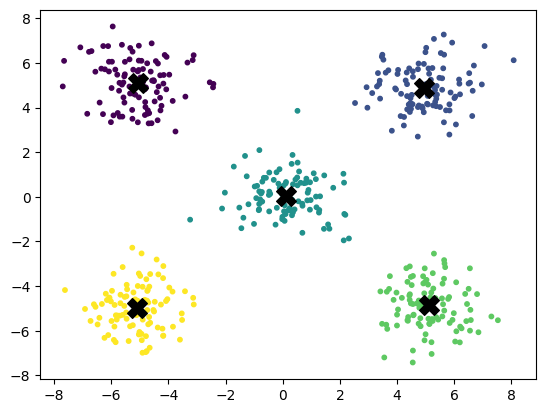

In [3]:
from matplotlib.axes import Axes

def draw_knn_graph(X, y_pred, kmeans, ax: Axes) -> Axes:
    ax.scatter(X[:, 0], X[:, 1], c=y_pred, s=10)
    cluster_center = kmeans.cluster_centers_
    ax.scatter(cluster_center[:, 0], cluster_center[:, 1], marker='X', s=200, c='black')
    return ax

fig, ax = plt.subplots(1,1)
draw_knn_graph(X, y_pred, kmeans, ax)

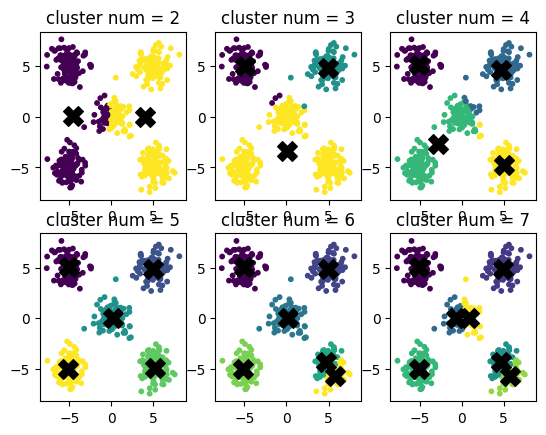

In [4]:
from sklearn.metrics import silhouette_score

fig, ax = plt.subplots(2,3)
scores = []

for n, ax in enumerate(ax.flat, start=2):
    model = KMeans(n_clusters=n, random_state=42)
    y_pred = model.fit_predict(X)
    scores.append(silhouette_score(X, y_pred))
    draw_knn_graph(X, y_pred, model, ax=ax)
    ax.set_title(f"cluster num = {n}")

plt.show()

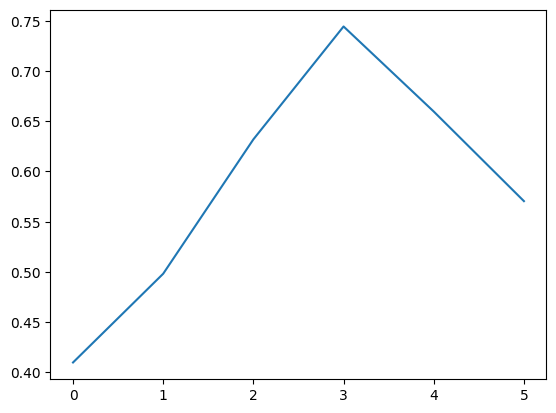

In [5]:
plt.plot(scores)

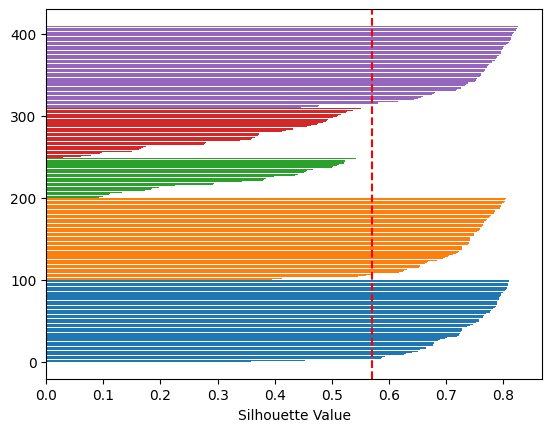

In [6]:
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, ax = plt.subplots()
y_lower = 0

for i in range(k):
    values = silhouette_samples(X, y_pred)[y_pred == i]
    values.sort()
    ax.barh(range(y_lower, y_lower + len(values)), values)
    y_lower += len(values)

ax.axvline(x=silhouette_score(X, y_pred), color='red', linestyle='--')
plt.xlabel('Silhouette Value')
plt.show()